In [1]:
import os
import re
import time
import math
import string
import random
import joblib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import StratifiedKFold, GroupKFold, KFold
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
from textwrap import wrap
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential, load_model
from keras.layers import Dense, Embedding, LSTM, Dropout, Flatten, Conv1D, GlobalMaxPooling1D, MaxPooling1D, SpatialDropout1D, GRU, Bidirectional
from keras.initializers import Constant
from keras.callbacks import ModelCheckpoint
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, SGD, AdamW
from torch.utils.data import DataLoader, Dataset
import transformers
from transformers import AutoTokenizer, AutoModel, AutoConfig
from transformers import get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score
from tqdm import tqdm

warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))
plt.rcParams['figure.figsize'] = 12, 8
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')


2024-07-01 20:43:20.404715: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-01 20:43:20.404836: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-01 20:43:20.539046: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
import pandas as pd
datapath = '/kaggle/input/binary-bd-hate-speech/Binary_BDHate.xlsx'
df = pd.read_excel(datapath)
df.head()

,Comments,Label,Category
0,ভারত সবদেশের শত্রু আর যারা বাংলাদেশর বিরোধিতা ...,1,anti-political
1,ইন্ডিয়ার সব মানুষ নাকি শিক্ষিত হাহাহা ফইন্নিরা...,1,anti-political
2,ভারত যখন বাংলাদেশি মারে তখন বাংলাদেশ কঠোর জবাব...,1,anti-political
3,যারা সবসময় গোবর খায় তারা তো গোবর নিয়েই চীন্তা ...,1,anti-political
4,বাংলাদেশে ভারতীয় কয় কোটি আছে দুষ্টরা এটা বলতে ...,1,anti-political


In [ ]:
import pandas as pd
datapath = '/kaggle/input/multi-hs/multi_HS.xlsx'
df = pd.read_excel(datapath)
df.head()

In [27]:
# Group by 'Label' and get the size of each group
label_counts = df.groupby(['Label']).size()

# Print the total data for each category
print("Total data for each category:")
print(label_counts)

Total data for each category:
Label
0    35002
1    30249
dtype: int64


In [4]:
# Group by 'Label' and get the size of each group
label_counts = df.groupby(['Category']).size()

# Print the total data for each category
print("Total data for each category:")
print(label_counts)

Total data for each category:
Category
anti-political    6050
anti-religious    6050
misogynist        6050
slander           6050
xenophobic        6050
dtype: int64


In [ ]:
def cleaning_data(row):
    text = re.sub('[^\u0980-\u09FF]',' ',str(row)) 
    return text

In [ ]:
import re

def cleaning_data(row):
    
    text = re.sub(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F700-\U0001F77F\U0001F780-\U0001F7FF\U0001F800-\U0001F8FF\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F\U0001FA70-\U0001FAFF\U00002702-\U000027B0\U000024C2-\U0001F251\U0001f926-\U0001f937\U0001F1E0-\U0001F1FF]', '', str(row))
    
    text = re.sub(r'[^\w\s\u0980-\u09FF]', '', text)
    return text


In [4]:
df['Comments'] = df['Comments'].apply(cleaning_data)

In [5]:
df.head()

,Comments,Label,Category
0,ভারত সবদেশের শত্রু আর যারা বাংলাদেশর বিরোধিতা ...,1,anti-political
1,ইন্ডিয়ার সব মানুষ নাকি শিক্ষিত হাহাহা ফইন্নিরা...,1,anti-political
2,ভারত যখন বাংলাদেশি মারে তখন বাংলাদেশ কঠোর জবাব...,1,anti-political
3,যারা সবসময় গোবর খায় তারা তো গোবর নিয়েই চীন্তা ...,1,anti-political
4,বাংলাদেশে ভারতীয় কয় কোটি আছে দুষ্টরা এটা বলতে ...,1,anti-political


# Muticlass Hate Speech Classification 

In [7]:
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

# Define the labels dictionary with a different name
label_dict = {
    'anti-political': 0,
    'anti-religious': 1,
    'misogynist': 2,
    'xenophobic': 4,
    'slander': 3
}

# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained('csebuetnlp/banglabert')

class HateSpeechDataset(Dataset):
    def __init__(self, texts, categories, tokenizer, max_len):
        self.texts = texts
        self.categories = categories
        self.tokenizer = tokenizer
        self.max_len = max_len

        # Encode categories manually using the label_dict dictionary
        self.labels = [label_dict[category] for category in categories]
        
        # Print labels with their actual names and encoded values
#         print("Labels with their actual names and encoded values:")
#         for category, encoded_value in zip(categories, self.labels):
#             print(f"{category}: {encoded_value}")

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        inputs = self.tokenizer(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_token_type_ids=False,
            return_attention_mask=True,
            return_tensors="pt",
        )

        return {
            "input_ids": inputs["input_ids"].flatten(),
            "attention_mask": inputs["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

# Assuming you have a dataframe `df` with 'Comments' and 'Category' columns
texts = df['Comments'].tolist()
categories = df['Category'].tolist()

# Split data into train, validation, and test sets
train_texts, test_texts, train_labels, test_labels = train_test_split(texts, categories, test_size=0.2, random_state=42, stratify=categories)
val_texts, test_texts, val_labels, test_labels = train_test_split(test_texts, test_labels, test_size=0.5, random_state=42, shuffle=False)

# Define training, validation, and test datasets
train_dataset = HateSpeechDataset(train_texts, train_labels, tokenizer, max_len=50)
val_dataset = HateSpeechDataset(val_texts, val_labels, tokenizer, max_len=50)
test_dataset = HateSpeechDataset(test_texts, test_labels, tokenizer, max_len=50)

# Define dataloaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))


24200
3025
3025


In [ ]:

token_lens = []
for txt in df.Comments:
  tokens = tokenizer.encode(txt, max_length=512,truncation=True)
  token_lens.append(len(tokens))

BERT-LSTM-Global-Max-Pooling

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

class BertLSTMClassifier(nn.Module):
    def __init__(self, bert_model, lstm_hidden_size, num_classes):
        super(BertLSTMClassifier, self).__init__()
        self.bert = bert_model
        self.lstm1 = nn.LSTM(input_size=self.bert.config.hidden_size,
                             hidden_size=lstm_hidden_size,
                             num_layers=1,
                             batch_first=True,
                             dropout=0.3,
                             bidirectional=False)
        self.dropout1 = nn.Dropout(0.3)
        self.lstm2 = nn.LSTM(input_size=lstm_hidden_size,
                             hidden_size=lstm_hidden_size,
                             num_layers=1,
                             batch_first=True,
                             dropout=0.3,
                             bidirectional=False)
        self.dropout2 = nn.Dropout(0.3)
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(lstm_hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        # BERT encoding
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        bert_output = outputs.last_hidden_state

        # First LSTM layer
        lstm_output1, _ = self.lstm1(bert_output)
        lstm_output1 = self.dropout1(lstm_output1)

        # Second LSTM layer
        lstm_output2, _ = self.lstm2(lstm_output1)
        lstm_output2, _ = self.dropout2(lstm_output2)
        # Global Max Pooling
        lstm_output2 = lstm_output2.permute(0, 2, 1)
        pooled_output = self.global_max_pool(lstm_output2).squeeze(2)

        # # Dropout layer
        # pooled_output = self.dropout2(pooled_output)

        # Classification layer
        logits = self.fc(pooled_output)

        return logits
def train(model, train_loader, val_loader, optimizer, criterion, scheduler, device, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        progress_bar_train = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs} - Training')
        for batch in progress_bar_train:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            progress_bar_train.set_postfix({'Train Loss': total_loss / total_samples,
                                            'Train Accuracy': total_correct / total_samples})

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {total_loss / total_samples:.4f}, "
              f"Train Accuracy: {total_correct / total_samples:.4f}, "
              f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        # Step the scheduler after each epoch
        scheduler.step()

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = total_correct / total_samples

    return val_loss, val_accuracy

def test(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / len(test_loader)
    test_accuracy = total_correct / total_samples

    return test_loss, test_accuracy, all_predictions, all_labels

# Initialize the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained('csebuetnlp/banglabert')
model = BertLSTMClassifier(AutoModel.from_pretrained('csebuetnlp/banglabert'), lstm_hidden_size=512, num_classes=5)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and criterion
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# Define the learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)

# Train the model
train(model, train_loader, val_loader, optimizer, criterion, scheduler, device, epochs=10)



Epoch 1/10 - Training: 100%|██████████| 3025/3025 [03:50<00:00, 13.11it/s, Train Loss=0.0621, Train Accuracy=0.828]


Epoch 1/10, Train Loss: 0.0621, Train Accuracy: 0.8277, Validation Loss: 0.3260, Validation Accuracy: 0.8969


Epoch 2/10 - Training: 100%|██████████| 3025/3025 [03:50<00:00, 13.13it/s, Train Loss=0.0348, Train Accuracy=0.907]


Epoch 2/10, Train Loss: 0.0348, Train Accuracy: 0.9067, Validation Loss: 0.2987, Validation Accuracy: 0.9041


Epoch 3/10 - Training: 100%|██████████| 3025/3025 [03:50<00:00, 13.15it/s, Train Loss=0.0256, Train Accuracy=0.929]


...

Epoch 8/10, Train Loss: 0.0088, Train Accuracy: 0.9702, Validation Loss: 0.3885, Validation Accuracy: 0.9031


Epoch 9/10 - Training: 100%|██████████| 3025/3025 [03:50<00:00, 13.11it/s, Train Loss=0.00758, Train Accuracy=0.974]


Epoch 9/10, Train Loss: 0.0076, Train Accuracy: 0.9743, Validation Loss: 0.3793, Validation Accuracy: 0.9084


Epoch 10/10 - Training: 100%|██████████| 3025/3025 [03:50<00:00, 13.10it/s, Train Loss=0.00674, Train Accuracy=0.974]


Epoch 10/10, Train Loss: 0.0067, Train Accuracy: 0.9743, Validation Loss: 0.4430, Validation Accuracy: 0.9021


HateBert-MLP

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score
from tqdm import tqdm

class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_classes):
        super(BertClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.3)  # Dropout layer
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)  # Classification layer

    def forward(self, input_ids, attention_mask):
        # BERT encoding
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state  # Extract last hidden state
        
        # Use the [CLS] token representation (first token)
        cls_output = last_hidden_state[:, 0, :]
        
        # Dropout layer
        cls_output = self.dropout(cls_output)
        
        # Classification layer
        logits = self.fc(cls_output)
        
        return logits

def train(model, train_loader, val_loader, optimizer, criterion, device, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        progress_bar_train = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs} - Training')
        for batch in progress_bar_train:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            progress_bar_train.set_postfix({'Train Loss': total_loss / total_samples,
                                            'Train Accuracy': total_correct / total_samples})

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {total_loss / total_samples:.4f}, "
              f"Train Accuracy: {total_correct / total_samples:.4f}, "
              f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = total_correct / total_samples

    return val_loss, val_accuracy

# Initialize the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained('csebuetnlp/banglabert')
model = BertClassifier(AutoModel.from_pretrained('csebuetnlp/banglabert'), num_classes=5)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and criterion
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# # Dummy data loaders (replace with actual data loaders)
# train_loader = DataLoader(Dataset(), batch_size=32, shuffle=True)
# val_loader = DataLoader(Dataset(), batch_size=32)

# Train the model
train(model, train_loader, val_loader, optimizer, criterion, device, epochs=20)



Epoch 1/20 - Training: 100%|██████████| 3025/3025 [03:17<00:00, 15.34it/s, Train Loss=0.0516, Train Accuracy=0.858]


Epoch 1/20, Train Loss: 0.0516, Train Accuracy: 0.8579, Validation Loss: 0.3275, Validation Accuracy: 0.8800


Epoch 2/20 - Training: 100%|██████████| 3025/3025 [03:16<00:00, 15.36it/s, Train Loss=0.0315, Train Accuracy=0.914]


Epoch 2/20, Train Loss: 0.0315, Train Accuracy: 0.9142, Validation Loss: 0.3195, Validation Accuracy: 0.8975


Epoch 3/20 - Training: 100%|██████████| 3025/3025 [03:16<00:00, 15.42it/s, Train Loss=0.0235, Train Accuracy=0.935]


...

Epoch 18/20, Train Loss: 0.0045, Train Accuracy: 0.9826, Validation Loss: 0.6232, Validation Accuracy: 0.8979


Epoch 19/20 - Training: 100%|██████████| 3025/3025 [03:16<00:00, 15.40it/s, Train Loss=0.00429, Train Accuracy=0.983]


Epoch 19/20, Train Loss: 0.0043, Train Accuracy: 0.9834, Validation Loss: 0.6414, Validation Accuracy: 0.8889


Epoch 20/20 - Training:  38%|███▊      | 1147/3025 [01:14<02:02, 15.39it/s, Train Loss=0.00351, Train Accuracy=0.985]


KeyboardInterrupt: 

BERT-CNN

In [15]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score
from tqdm import tqdm

class BertCNNClassifier(nn.Module):
    def __init__(self, bert_model, num_classes, num_filters, kernel_size, dropout_rate):
        super(BertCNNClassifier, self).__init__()
        self.bert = bert_model
        self.conv1 = nn.Conv1d(in_channels=self.bert.config.hidden_size,
                               out_channels=num_filters,
                               kernel_size=kernel_size,
                               padding=1)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.conv2 = nn.Conv1d(in_channels=num_filters,
                               out_channels=num_filters,
                               kernel_size=kernel_size,
                               padding=1)
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(num_filters, num_filters)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(num_filters, num_classes)

    def forward(self, input_ids, attention_mask):
        # BERT encoding
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        bert_output = outputs.last_hidden_state  # (batch_size, seq_len, hidden_size)

        # Permute to fit Conv1d layer input format (batch_size, hidden_size, seq_len)
        bert_output = bert_output.permute(0, 2, 1)

        # Conv1D layers
        conv1_output = torch.relu(self.conv1(bert_output))
        conv1_output = self.dropout1(conv1_output)
        conv2_output = torch.relu(self.conv2(conv1_output))

        # Global Max Pooling
        pooled_output = self.global_max_pool(conv2_output).squeeze(2)

        # Fully connected layers
        fc1_output = torch.relu(self.fc1(pooled_output))
        fc1_output = self.dropout2(fc1_output)
        logits = self.fc2(fc1_output)

        return logits

# Initialize the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained('csebuetnlp/banglabert')
model = BertCNNClassifier(AutoModel.from_pretrained('csebuetnlp/banglabert'), 
                          num_classes=5, 
                          num_filters=512, 
                          kernel_size=5, 
                          dropout_rate=0.2)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and criterion
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# Define the learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=2, verbose=True)

def train(model, train_loader, val_loader, optimizer, criterion, scheduler, device, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        progress_bar_train = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs} - Training')
        for batch in progress_bar_train:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            progress_bar_train.set_postfix({'Train Loss': total_loss / total_samples,
                                            'Train Accuracy': total_correct / total_samples})

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {total_loss / total_samples:.4f}, "
              f"Train Accuracy: {total_correct / total_samples:.4f}, "
              f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        # Step the scheduler with the validation accuracy
        scheduler.step(val_accuracy)

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = total_correct / total_samples

    return val_loss, val_accuracy


# Train the model
train(model, train_loader, val_loader, optimizer, criterion, scheduler, device, epochs=15)



Epoch 1/15 - Training: 100%|██████████| 3025/3025 [03:26<00:00, 14.66it/s, Train Loss=0.0597, Train Accuracy=0.823]


Epoch 1/15, Train Loss: 0.0597, Train Accuracy: 0.8234, Validation Loss: 0.3316, Validation Accuracy: 0.8889


Epoch 2/15 - Training: 100%|██████████| 3025/3025 [03:26<00:00, 14.65it/s, Train Loss=0.0347, Train Accuracy=0.906]


Epoch 2/15, Train Loss: 0.0347, Train Accuracy: 0.9059, Validation Loss: 0.2995, Validation Accuracy: 0.9012


Epoch 3/15 - Training: 100%|██████████| 3025/3025 [03:26<00:00, 14.65it/s, Train Loss=0.0265, Train Accuracy=0.926]


...

Epoch 13/15, Train Loss: 0.0031, Train Accuracy: 0.9872, Validation Loss: 0.6015, Validation Accuracy: 0.9025


Epoch 14/15 - Training: 100%|██████████| 3025/3025 [03:26<00:00, 14.63it/s, Train Loss=0.00315, Train Accuracy=0.987]


Epoch 14/15, Train Loss: 0.0032, Train Accuracy: 0.9868, Validation Loss: 0.6093, Validation Accuracy: 0.9021
Epoch 00014: reducing learning rate of group 0 to 2.0000e-08.


Epoch 15/15 - Training: 100%|██████████| 3025/3025 [03:26<00:00, 14.62it/s, Train Loss=0.00304, Train Accuracy=0.988]


Epoch 15/15, Train Loss: 0.0030, Train Accuracy: 0.9879, Validation Loss: 0.6101, Validation Accuracy: 0.9021


Model Test For BERT-CNN

In [42]:
# Define a function to load the model weights
def load_model(model, path, device):
    model.load_state_dict(torch.load(path))
    model.to(device)
    print(f"Model loaded from {path}")

# Example: Load the final model weights
load_model(model, os.path.join(save_path, "Multi_model_final.pth"), device)

Model loaded from ./model_weights/Multi_model_final.pth


In [16]:
from sklearn.metrics import classification_report

def test(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / len(test_loader)
    test_accuracy = total_correct / total_samples

    return test_loss, test_accuracy, all_predictions, all_labels

# Test the model
test_loss, test_accuracy, all_predictions, all_labels = test(model, test_loader, criterion, device)

# Calculate classification report
target_names = ['PoHS', 'ReHS', 'MisoHS', 'SlaHS', 'XenHS'] 
print("Test Loss: {:.4f}, Test Accuracy: {:.4f}".format(test_loss, test_accuracy))
print(classification_report(all_labels, all_predictions, target_names=target_names))

Test Loss: 0.6073, Test Accuracy: 0.8972
              precision    recall  f1-score   support

        PoHS       0.87      0.89      0.88       624
        ReHS       0.93      0.94      0.93       607
      MisoHS       0.89      0.86      0.87       595
       SlaHS       0.81      0.80      0.81       599
       XenHS       1.00      0.99      0.99       600

    accuracy                           0.90      3025
   macro avg       0.90      0.90      0.90      3025
weighted avg       0.90      0.90      0.90      3025



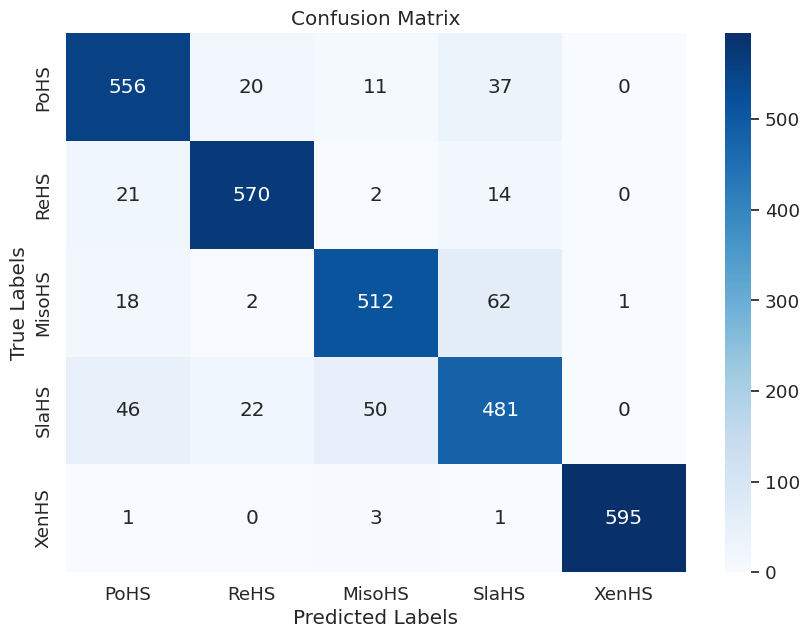

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Create the figure
plt.figure(figsize=(10, 7))

# Plot the heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)

# Add labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')

# Save the figure
plt.savefig('Multi_confusion_matrix.png')

# Show the plot
plt.show()


In [19]:
# Error analysis: Identify misclassified examples
misclassified_indices = np.where(np.array(all_labels) != np.array(all_predictions))[0]
print(f"Number of misclassified samples: {len(misclassified_indices)}")

# Display some misclassified examples
for i in misclassified_indices[:15]:  # Display first 5 misclassified examples
    input_ids = test_loader.dataset[i]["input_ids"]
    true_label = target_names[test_loader.dataset[i]["labels"]]
    predicted_label = target_names[all_predictions[i]]
    input_text = tokenizer.decode(input_ids, skip_special_tokens=True)
    print(f"Text: {input_text}")
    print(f"True Label: {true_label}, Predicted Label: {predicted_label}\n")

Number of misclassified samples: 311
Text: ভাবী তোমার হট দেবর আমি কেমন আছেন আপনি মিস দাও
True Label: MisoHS, Predicted Label: SlaHS

Text: রাস্তার ম সাড়ে দশটা থেকে সাড়ে ঠেলা খাইতে ভালো লাগছেনা শালিমা আগে পুলিশ প্রশাসনের এখন উচিত দরকার ছিল সোনার মধ্যে মরিচ দি যোগাযোগ
True Label: SlaHS, Predicted Label: PoHS

Text: সময় আর বেশী দিন নাই এই ইহুদি সরকার দের পতন ঘটবে
True Label: PoHS, Predicted Label: ReHS

Text: এ আজ জন মুসলমান কে আজ সেনা ও সূচি সরকার হত্যা করসেতোরা সাংবাদিক কুত্তার বাচ্চা রা এর কোনো প্রতিবাদ করস না কেনবাংলাদেশের খানকির পোলা চুপ করে একটা হিন্দু মরত তাহলে কুত্তার বাচ্চা ঘেউ
True Label: PoHS, Predicted Label: ReHS

Text: সোনা পুটকিতে তাই সে চেলফি তুলেছে
True Label: SlaHS, Predicted Label: MisoHS

Text: মীর জাফরের মুখে মুতে দে
True Label: SlaHS, Predicted Label: PoHS

Text: বাংলা চীনি ভাই ভাই সাহায্যের নামে পোদ মাইরা লিবে তোরা বলদ চোদার দল এইটা কি বুঝোস্ নাই
True Label: SlaHS, Predicted Label: MisoHS

Text: ভাই শার্টের থেকে পকেট
True Label: PoHS, Predicted Label: MisoHS

Tex

In [14]:
#128, 5, 10, 0.1
import os

# Save the trained model weights
save_path = "./model_weights"
os.makedirs(save_path, exist_ok=True)
torch.save(model.state_dict(), os.path.join(save_path, "Multi_model_final_128.pth"))

print(f"Model weights saved to {os.path.join(save_path, 'Multi_model_final_128.pth')}")

Model weights saved to ./model_weights/Multi_model_final_128.pth


In [20]:
import os

# Save the trained model weights
save_path = "./model_weights"
os.makedirs(save_path, exist_ok=True)
torch.save(model.state_dict(), os.path.join(save_path, "Multi_model_final_512.pth"))

print(f"Model weights saved to {os.path.join(save_path, 'Multi_model_final_512.pth')}")

Model weights saved to ./model_weights/Multi_model_final_512.pth


# Binary Hate Speech Classification 

In [22]:
import pandas as pd
datapath = '/kaggle/input/binary-bd-hate-speech/Binary_BDHate.xlsx'
df = pd.read_excel(datapath)
df.head()

,Comments,Label,Category
0,ভারত সবদেশের শত্রু আর যারা বাংলাদেশর বিরোধিতা ...,1,anti-political
1,ইন্ডিয়ার সব মানুষ নাকি শিক্ষিত হাহাহা ফইন্নিরা...,1,anti-political
2,ভারত যখন বাংলাদেশি মারে তখন বাংলাদেশ কঠোর জবাব...,1,anti-political
3,যারা সবসময় গোবর খায় তারা তো গোবর নিয়েই চীন্তা ...,1,anti-political
4,বাংলাদেশে ভারতীয় কয় কোটি আছে দুষ্টরা এটা বলতে ...,1,anti-political


In [23]:
import re

def cleaning_data(row):
    # Remove emojis
    text = re.sub(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F700-\U0001F77F\U0001F780-\U0001F7FF\U0001F800-\U0001F8FF\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F\U0001FA70-\U0001FAFF\U00002702-\U000027B0\U000024C2-\U0001F251\U0001f926-\U0001f937\U0001F1E0-\U0001F1FF]', '', str(row))
    # Remove unnecessary punctuation and non-Bangla characters
    text = re.sub(r'[^\w\s\u0980-\u09FF]', '', text)
    return text

In [24]:
df['Comments'] = df['Comments'].apply(cleaning_data)

In [25]:
df.head()

,Comments,Label,Category
0,ভারত সবদেশের শত্রু আর যারা বাংলাদেশর বিরোধিতা ...,1,anti-political
1,ইন্ডিয়ার সব মানুষ নাকি শিক্ষিত হাহাহা ফইন্নিরা...,1,anti-political
2,ভারত যখন বাংলাদেশি মারে তখন বাংলাদেশ কঠোর জবাব...,1,anti-political
3,যারা সবসময় গোবর খায় তারা তো গোবর নিয়েই চীন্তা ...,1,anti-political
4,বাংলাদেশে ভারতীয় কয় কোটি আছে দুষ্টরা এটা বলতে ...,1,anti-political


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained('csebuetnlp/banglabert')

class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        inputs = self.tokenizer(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_token_type_ids=False,
            return_attention_mask=True,
            return_tensors="pt",
        )

        return {
            "input_ids": inputs["input_ids"].flatten(),
            "attention_mask": inputs["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

# Assuming you have a dataframe `df` with 'Comments' and 'Labels' columns
texts = df['Comments'].tolist()
labels = df['Label'].tolist()

# Split data into train, validation, and test sets
train_texts, test_texts, train_labels, test_labels = train_test_split(texts, labels, test_size=0.2, random_state=42, stratify=labels)
val_texts, test_texts, val_labels, test_labels = train_test_split(test_texts, test_labels, test_size=0.5, random_state=42, shuffle=False)

# Define training, validation, and test datasets
train_dataset = HateSpeechDataset(train_texts, train_labels, tokenizer, max_len=50)
val_dataset = HateSpeechDataset(val_texts, val_labels, tokenizer, max_len=50)
test_dataset = HateSpeechDataset(test_texts, test_labels, tokenizer, max_len=50)

# Define dataloaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))


52200
6525
6526


Main

In [29]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score
from tqdm import tqdm

class BertCNNClassifier(nn.Module):
    def __init__(self, bert_model, num_classes, num_filters, kernel_size, dropout_rate):
        super(BertCNNClassifier, self).__init__()
        self.bert = bert_model
        self.conv1 = nn.Conv1d(in_channels=self.bert.config.hidden_size,
                               out_channels=num_filters,
                               kernel_size=kernel_size,
                               padding=1)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.conv2 = nn.Conv1d(in_channels=num_filters,
                               out_channels=num_filters,
                               kernel_size=kernel_size,
                               padding=1)
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(num_filters, num_filters)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(num_filters, num_classes)

    def forward(self, input_ids, attention_mask):
        # BERT encoding
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        bert_output = outputs.last_hidden_state  # (batch_size, seq_len, hidden_size)

        # Permute to fit Conv1d layer input format (batch_size, hidden_size, seq_len)
        bert_output = bert_output.permute(0, 2, 1)

        # Conv1D layers
        conv1_output = torch.relu(self.conv1(bert_output))
        conv1_output = self.dropout1(conv1_output)
        conv2_output = torch.relu(self.conv2(conv1_output))

        # Global Max Pooling
        pooled_output = self.global_max_pool(conv2_output).squeeze(2)

        # Fully connected layers
        fc1_output = torch.relu(self.fc1(pooled_output))
        fc1_output = self.dropout2(fc1_output)
        logits = self.fc2(fc1_output)

        return logits

# Initialize the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained('csebuetnlp/banglabert')
model = BertCNNClassifier(AutoModel.from_pretrained('csebuetnlp/banglabert'), 
                          num_classes=2, 
                          num_filters=512, 
                          kernel_size=3, 
                          dropout_rate=0.2)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and criterion
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

# Define the learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=1, verbose=True)

def train(model, train_loader, val_loader, optimizer, criterion, scheduler, device, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        progress_bar_train = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs} - Training')
        for batch in progress_bar_train:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            progress_bar_train.set_postfix({'Train Loss': total_loss / total_samples,
                                            'Train Accuracy': total_correct / total_samples})

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {total_loss / total_samples:.4f}, "
              f"Train Accuracy: {total_correct / total_samples:.4f}, "
              f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        # Step the scheduler with the validation accuracy
        scheduler.step(val_accuracy)

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = total_correct / total_samples

    return val_loss, val_accuracy

# Assume train_loader and val_loader are already defined
# Train the model
train(model, train_loader, val_loader, optimizer, criterion, scheduler, device, epochs=10)


Epoch 1/10 - Training: 100%|██████████| 6525/6525 [07:17<00:00, 14.92it/s, Train Loss=0.034, Train Accuracy=0.885] 


Epoch 1/10, Train Loss: 0.0340, Train Accuracy: 0.8848, Validation Loss: 0.2277, Validation Accuracy: 0.9034


Epoch 2/10 - Training: 100%|██████████| 6525/6525 [07:16<00:00, 14.94it/s, Train Loss=0.0217, Train Accuracy=0.931]


Epoch 2/10, Train Loss: 0.0217, Train Accuracy: 0.9307, Validation Loss: 0.2114, Validation Accuracy: 0.9102


Epoch 3/10 - Training: 100%|██████████| 6525/6525 [07:17<00:00, 14.93it/s, Train Loss=0.0138, Train Accuracy=0.958]


...

Epoch 8/10, Train Loss: 0.0028, Train Accuracy: 0.9917, Validation Loss: 0.3946, Validation Accuracy: 0.9198


Epoch 9/10 - Training: 100%|██████████| 6525/6525 [07:15<00:00, 14.97it/s, Train Loss=0.0026, Train Accuracy=0.993] 


Epoch 9/10, Train Loss: 0.0026, Train Accuracy: 0.9929, Validation Loss: 0.3764, Validation Accuracy: 0.9175
Epoch 00009: reducing learning rate of group 0 to 1.0000e-06.


Epoch 10/10 - Training: 100%|██████████| 6525/6525 [07:16<00:00, 14.94it/s, Train Loss=0.000972, Train Accuracy=0.997]


Epoch 10/10, Train Loss: 0.0010, Train Accuracy: 0.9972, Validation Loss: 0.5132, Validation Accuracy: 0.9189


In [22]:
# Test the model
test_loss, test_accuracy, all_predictions, all_labels = test(model, test_loader, criterion, device)

# Calculate classification report
target_names = ['NHS', 'HS']
print("Test Loss: {:.4f}, Test Accuracy: {:.4f}".format(test_loss, test_accuracy))
print(classification_report(all_labels, all_predictions, target_names=target_names))





Test Loss: 0.5195, Test Accuracy: 0.9174
              precision    recall  f1-score   support

         NHS       0.92      0.92      0.92      3479
          HS       0.91      0.91      0.91      3047

    accuracy                           0.92      6526
   macro avg       0.92      0.92      0.92      6526
weighted avg       0.92      0.92      0.92      6526



In [35]:
# Test the model
test_loss, test_accuracy, all_predictions, all_labels = test(model, test_loader, criterion, device)

# Calculate classification report
target_names = ['NHS', 'HS']
print("Test Loss: {:.4f}, Test Accuracy: {:.4f}".format(test_loss, test_accuracy))
print(classification_report(all_labels, all_predictions, target_names=target_names))


Test Loss: 0.5195, Test Accuracy: 0.9174
              precision    recall  f1-score   support

         NHS       0.92      0.92      0.92      3479
          HS       0.91      0.91      0.91      3047

    accuracy                           0.92      6526
   macro avg       0.92      0.92      0.92      6526
weighted avg       0.92      0.92      0.92      6526



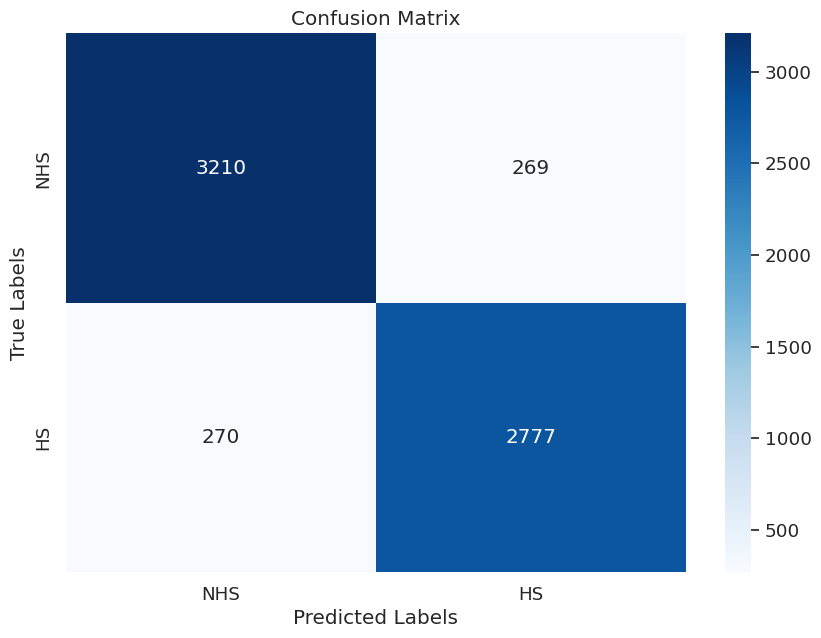

In [36]:
# Generate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('binary_confusion_matrix.png')
plt.show()

In [37]:
# Error analysis: Identify misclassified examples
misclassified_indices = np.where(np.array(all_labels) != np.array(all_predictions))[0]
print(f"Number of misclassified samples: {len(misclassified_indices)}")

# Display some misclassified examples
for i in misclassified_indices[:5]:  # Display first 5 misclassified examples
    input_ids = test_loader.dataset[i]["input_ids"]
    true_label = target_names[test_loader.dataset[i]["labels"]]
    predicted_label = target_names[all_predictions[i]]
    input_text = tokenizer.decode(input_ids, skip_special_tokens=True)
    print(f"Text: {input_text}")
    print(f"True Label: {true_label}, Predicted Label: {predicted_label}\n")

Number of misclassified samples: 539
Text: এত খারাপ মানুষওকে ডিম থেরাপি দিতে হবে
True Label: HS, Predicted Label: NHS

Text: এই কাফেরের বাচ্চা মরনের চিনতা কর
True Label: NHS, Predicted Label: HS

Text: ভারত না পাকিস্তান টাইপে ভুল হইছে
True Label: HS, Predicted Label: NHS

Text: বিচার হবে
True Label: HS, Predicted Label: NHS

Text: উপরে বন্ধুদেশ বলে আর অপেক্ষাই থাকে ক্ষতিসাধন করতেমুত্র পানকারী আর কেউ না এই বুজলে খান
True Label: NHS, Predicted Label: HS



In [20]:
import os

# Save the trained model weights
save_path = "./model_weights"
os.makedirs(save_path, exist_ok=True)
torch.save(model.state_dict(), os.path.join(save_path, "model_final.pth"))

print(f"Model weights saved to {os.path.join(save_path, 'model_final.pth')}")


Model weights saved to ./model_weights/model_final.pth


In [34]:
save_path = "/kaggle/input/128-bn-weights/"
# Define a function to load the model weights
def load_model(model, path, device):
    model.load_state_dict(torch.load(path))
    model.to(device)
    print(f"Model loaded from {path}")

# Example: Load the final model weights
load_model(model, os.path.join(save_path, "model_final (3).pth"), device)

Model loaded from /kaggle/input/128-bn-weights/model_final (3).pth


# **Other SOTA Model**

**For Binary**

In [2]:
import pandas as pd
datapath = '/kaggle/input/binary-bd-hate-speech/Binary_BDHate.xlsx'
df = pd.read_excel(datapath)
df.head()

,Comments,Label,Category
0,ভারত সবদেশের শত্রু আর যারা বাংলাদেশর বিরোধিতা ...,1,anti-political
1,ইন্ডিয়ার সব মানুষ নাকি শিক্ষিত হাহাহা ফইন্নিরা...,1,anti-political
2,ভারত যখন বাংলাদেশি মারে তখন বাংলাদেশ কঠোর জবাব...,1,anti-political
3,যারা সবসময় গোবর খায় তারা তো গোবর নিয়েই চীন্তা ...,1,anti-political
4,বাংলাদেশে ভারতীয় কয় কোটি আছে দুষ্টরা এটা বলতে ...,1,anti-political


In [3]:
import re

def cleaning_data(row):
    # Remove emojis
    text = re.sub(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F700-\U0001F77F\U0001F780-\U0001F7FF\U0001F800-\U0001F8FF\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F\U0001FA70-\U0001FAFF\U00002702-\U000027B0\U000024C2-\U0001F251\U0001f926-\U0001f937\U0001F1E0-\U0001F1FF]', '', str(row))
    # Remove unnecessary punctuation and non-Bangla characters
    text = re.sub(r'[^\w\s\u0980-\u09FF]', '', text)
    return text


In [4]:
df['Comments'] = df['Comments'].apply(cleaning_data)

In [6]:
df.head()

,Comments,Label,Category
0,ভারত সবদেশের শত্রু আর যারা বাংলাদেশর বিরোধিতা ...,1,anti-political
1,ইন্ডিয়ার সব মানুষ নাকি শিক্ষিত হাহাহা ফইন্নিরা...,1,anti-political
2,ভারত যখন বাংলাদেশি মারে তখন বাংলাদেশ কঠোর জবাব...,1,anti-political
3,যারা সবসময় গোবর খায় তারা তো গোবর নিয়েই চীন্তা ...,1,anti-political
4,বাংলাদেশে ভারতীয় কয় কোটি আছে দুষ্টরা এটা বলতে ...,1,anti-political


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

# Initialize the tokenizer
# tokenizer = AutoTokenizer.from_pretrained('csebuetnlp/banglabert')
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-multilingual-cased')
# tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')

class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        inputs = self.tokenizer(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_token_type_ids=False,
            return_attention_mask=True,
            return_tensors="pt",
        )

        return {
            "input_ids": inputs["input_ids"].flatten(),
            "attention_mask": inputs["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

# Assuming you have a dataframe `df` with 'Comments' and 'Labels' columns
texts = df['Comments'].tolist()
labels = df['Label'].tolist()

# Split data into train, validation, and test sets
train_texts, test_texts, train_labels, test_labels = train_test_split(texts, labels, test_size=0.2, random_state=42, stratify=labels)
val_texts, test_texts, val_labels, test_labels = train_test_split(test_texts, test_labels, test_size=0.5, random_state=42, shuffle=False)

# Define training, validation, and test datasets
train_dataset = HateSpeechDataset(train_texts, train_labels, tokenizer, max_len=50)
val_dataset = HateSpeechDataset(val_texts, val_labels, tokenizer, max_len=50)
test_dataset = HateSpeechDataset(test_texts, test_labels, tokenizer, max_len=50)

# Define dataloaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8,shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8,shuffle=False)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

52200
6525
6526


Bangla-Bert 

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score
from tqdm import tqdm

class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_classes):
        super(BertClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.3)  # Dropout layer
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)  # Classification layer

    def forward(self, input_ids, attention_mask):
        # BERT encoding
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state  # Extract last hidden state
        
        # Use the [CLS] token representation (first token)
        cls_output = last_hidden_state[:, 0, :]
        
        # Dropout layer
        cls_output = self.dropout(cls_output)
        
        # Classification layer
        logits = self.fc(cls_output)
        
        return logits

def train(model, train_loader, val_loader, optimizer, criterion, device, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        progress_bar_train = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs} - Training')
        for batch in progress_bar_train:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            progress_bar_train.set_postfix({'Train Loss': total_loss / total_samples,
                                            'Train Accuracy': total_correct / total_samples})

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {total_loss / total_samples:.4f}, "
              f"Train Accuracy: {total_correct / total_samples:.4f}, "
              f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = total_correct / total_samples

    return val_loss, val_accuracy

# Initialize the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained('csebuetnlp/banglabert')
model = BertClassifier(AutoModel.from_pretrained('csebuetnlp/banglabert'), num_classes=2)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and criterion
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# # Dummy data loaders (replace with actual data loaders)
# train_loader = DataLoader(Dataset(), batch_size=32, shuffle=True)
# val_loader = DataLoader(Dataset(), batch_size=32)

# Train the model
train(model, train_loader, val_loader, optimizer, criterion, device, epochs=10)



Epoch 1/10 - Training: 100%|██████████| 6525/6525 [06:55<00:00, 15.71it/s, Train Loss=0.0327, Train Accuracy=0.89] 


Epoch 1/10, Train Loss: 0.0327, Train Accuracy: 0.8899, Validation Loss: 0.2546, Validation Accuracy: 0.8941


Epoch 2/10 - Training: 100%|██████████| 6525/6525 [06:55<00:00, 15.69it/s, Train Loss=0.0209, Train Accuracy=0.934]


Epoch 2/10, Train Loss: 0.0209, Train Accuracy: 0.9339, Validation Loss: 0.2200, Validation Accuracy: 0.9179


Epoch 3/10 - Training: 100%|██████████| 6525/6525 [06:55<00:00, 15.70it/s, Train Loss=0.0124, Train Accuracy=0.963]


...

Epoch 8/10, Train Loss: 0.0029, Train Accuracy: 0.9920, Validation Loss: 0.3932, Validation Accuracy: 0.9209


Epoch 9/10 - Training: 100%|██████████| 6525/6525 [07:00<00:00, 15.52it/s, Train Loss=0.00236, Train Accuracy=0.993]


Epoch 9/10, Train Loss: 0.0024, Train Accuracy: 0.9934, Validation Loss: 0.5145, Validation Accuracy: 0.9191


Epoch 10/10 - Training: 100%|██████████| 6525/6525 [06:57<00:00, 15.63it/s, Train Loss=0.00221, Train Accuracy=0.994]


Epoch 10/10, Train Loss: 0.0022, Train Accuracy: 0.9942, Validation Loss: 0.5114, Validation Accuracy: 0.9113


In [13]:
def test(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / len(test_loader)
    test_accuracy = total_correct / total_samples

    return test_loss, test_accuracy, all_predictions, all_labels


# Test the model
test_loss, test_accuracy, all_predictions, all_labels = test(model, test_loader, criterion, device)

# Calculate classification report
target_names = ['NHS', 'HS']
print("Test Loss: {:.4f}, Test Accuracy: {:.4f}".format(test_loss, test_accuracy))
print(classification_report(all_labels, all_predictions, target_names=target_names))

Test Loss: 0.5351, Test Accuracy: 0.9071
              precision    recall  f1-score   support

         NHS       0.93      0.89      0.91      3479
          HS       0.88      0.93      0.90      3047

    accuracy                           0.91      6526
   macro avg       0.91      0.91      0.91      6526
weighted avg       0.91      0.91      0.91      6526



M-Bert

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score
from tqdm import tqdm

class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_classes):
        super(BertClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.3)  # Dropout layer
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)  # Classification layer

    def forward(self, input_ids, attention_mask):
        # BERT encoding
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state  # Extract last hidden state
        
        # Use the [CLS] token representation (first token)
        cls_output = last_hidden_state[:, 0, :]
        
        # Dropout layer
        cls_output = self.dropout(cls_output)
        
        # Classification layer
        logits = self.fc(cls_output)
        
        return logits

def train(model, train_loader, val_loader, optimizer, criterion, device, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        progress_bar_train = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs} - Training')
        for batch in progress_bar_train:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            progress_bar_train.set_postfix({'Train Loss': total_loss / total_samples,
                                            'Train Accuracy': total_correct / total_samples})

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {total_loss / total_samples:.4f}, "
              f"Train Accuracy: {total_correct / total_samples:.4f}, "
              f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = total_correct / total_samples

    return val_loss, val_accuracy

# Initialize the tokenizer and model for M-BERT
tokenizer = AutoTokenizer.from_pretrained('bert-base-multilingual-cased')
model = BertClassifier(AutoModel.from_pretrained('bert-base-multilingual-cased'), num_classes=2)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and criterion
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# # Dummy data loaders (replace with actual data loaders)
# train_loader = DataLoader(Dataset(), batch_size=32, shuffle=True)
# val_loader = DataLoader(Dataset(), batch_size=32)

# Train the model
train(model, train_loader, val_loader, optimizer, criterion, device, epochs=10)


Epoch 1/10 - Training: 100%|██████████| 6525/6525 [08:00<00:00, 13.57it/s, Train Loss=0.0511, Train Accuracy=0.808]


Epoch 1/10, Train Loss: 0.0511, Train Accuracy: 0.8081, Validation Loss: 0.2928, Validation Accuracy: 0.8760


Epoch 2/10 - Training: 100%|██████████| 6525/6525 [08:01<00:00, 13.56it/s, Train Loss=0.033, Train Accuracy=0.892] 


Epoch 2/10, Train Loss: 0.0330, Train Accuracy: 0.8924, Validation Loss: 0.2831, Validation Accuracy: 0.8743


Epoch 3/10 - Training: 100%|██████████| 6525/6525 [08:00<00:00, 13.58it/s, Train Loss=0.0264, Train Accuracy=0.918]


...

Epoch 8/10, Train Loss: 0.0172, Train Accuracy: 0.9549, Validation Loss: 0.3360, Validation Accuracy: 0.8889


Epoch 9/10 - Training: 100%|██████████| 6525/6525 [08:02<00:00, 13.54it/s, Train Loss=0.0131, Train Accuracy=0.965]


Epoch 9/10, Train Loss: 0.0131, Train Accuracy: 0.9651, Validation Loss: 0.3328, Validation Accuracy: 0.8985


Epoch 10/10 - Training: 100%|██████████| 6525/6525 [08:04<00:00, 13.46it/s, Train Loss=0.00852, Train Accuracy=0.979]


Epoch 10/10, Train Loss: 0.0085, Train Accuracy: 0.9790, Validation Loss: 0.3637, Validation Accuracy: 0.8941


In [23]:
def test(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / len(test_loader)
    test_accuracy = total_correct / total_samples

    return test_loss, test_accuracy, all_predictions, all_labels


# Test the model
test_loss, test_accuracy, all_predictions, all_labels = test(model, test_loader, criterion, device)

# Calculate classification report
target_names = ['NHS', 'HS']
print("Test Loss: {:.4f}, Test Accuracy: {:.4f}".format(test_loss, test_accuracy))
print(classification_report(all_labels, all_predictions, target_names=target_names))

Test Loss: 0.3529, Test Accuracy: 0.8990
              precision    recall  f1-score   support

         NHS       0.91      0.90      0.90      3479
          HS       0.88      0.90      0.89      3047

    accuracy                           0.90      6526
   macro avg       0.90      0.90      0.90      6526
weighted avg       0.90      0.90      0.90      6526



Distil-Bert

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score
from tqdm import tqdm

class DistilBertClassifier(nn.Module):
    def __init__(self, distilbert_model, num_classes):
        super(DistilBertClassifier, self).__init__()
        self.distilbert = distilbert_model
        self.dropout = nn.Dropout(0.3)  # Dropout layer
        self.fc = nn.Linear(self.distilbert.config.hidden_size, num_classes)  # Classification layer

    def forward(self, input_ids, attention_mask):
        # DistilBERT encoding
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = outputs.last_hidden_state  # Extract last hidden state
        
        # Use the [CLS] token representation (first token)
        cls_output = hidden_state[:, 0, :]
        
        # Dropout layer
        cls_output = self.dropout(cls_output)
        
        # Classification layer
        logits = self.fc(cls_output)
        
        return logits

def train(model, train_loader, val_loader, optimizer, criterion, device, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        progress_bar_train = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs} - Training')
        for batch in progress_bar_train:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            progress_bar_train.set_postfix({'Train Loss': total_loss / total_samples,
                                            'Train Accuracy': total_correct / total_samples})

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {total_loss / total_samples:.4f}, "
              f"Train Accuracy: {total_correct / total_samples:.4f}, "
              f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = total_correct / total_samples

    return val_loss, val_accuracy

# Initialize the tokenizer and model for DistilBERT
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-multilingual-cased')
model = DistilBertClassifier(AutoModel.from_pretrained('distilbert-base-multilingual-cased'), num_classes=2)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and criterion
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# # Dummy data loaders (replace with actual data loaders)
# train_loader = DataLoader(Dataset(), batch_size=32, shuffle=True)
# val_loader = DataLoader(Dataset(), batch_size=32)

# Train the model
train(model, train_loader, val_loader, optimizer, criterion, device, epochs=10)


model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Epoch 1/10 - Training:  62%|██████▏   | 4027/6525 [03:06<01:55, 21.71it/s, Train Loss=0.0437, Train Accuracy=0.846]

In [16]:
def test(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / len(test_loader)
    test_accuracy = total_correct / total_samples

    return test_loss, test_accuracy, all_predictions, all_labels


# Test the model
test_loss, test_accuracy, all_predictions, all_labels = test(model, test_loader, criterion, device)

# Calculate classification report
target_names = ['NHS', 'HS']
print("Test Loss: {:.4f}, Test Accuracy: {:.4f}".format(test_loss, test_accuracy))
print(classification_report(all_labels, all_predictions, target_names=target_names))

Test Loss: 0.3357, Test Accuracy: 0.8704
              precision    recall  f1-score   support

         NHS       0.90      0.85      0.88      3479
          HS       0.84      0.89      0.87      3047

    accuracy                           0.87      6526
   macro avg       0.87      0.87      0.87      6526
weighted avg       0.87      0.87      0.87      6526



XLM-R

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score
from tqdm import tqdm

class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_classes):
        super(BertClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.3)  # Dropout layer
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)  # Classification layer

    def forward(self, input_ids, attention_mask):
        # BERT encoding
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state  # Extract last hidden state
        
        # Use the [CLS] token representation (first token)
        cls_output = last_hidden_state[:, 0, :]
        
        # Dropout layer
        cls_output = self.dropout(cls_output)
        
        # Classification layer
        logits = self.fc(cls_output)
        
        return logits

def train(model, train_loader, val_loader, optimizer, criterion, device, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        progress_bar_train = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs} - Training')
        for batch in progress_bar_train:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            progress_bar_train.set_postfix({'Train Loss': total_loss / total_samples,
                                            'Train Accuracy': total_correct / total_samples})

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {total_loss / total_samples:.4f}, "
              f"Train Accuracy: {total_correct / total_samples:.4f}, "
              f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = total_correct / total_samples

    return val_loss, val_accuracy

# Initialize the tokenizer and model for XLM-R
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')
model = BertClassifier(AutoModel.from_pretrained('xlm-roberta-base'), num_classes=2)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and criterion
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# # Dummy data loaders (replace with actual data loaders)
# train_loader = DataLoader(Dataset(), batch_size=32, shuffle=True)
# val_loader = DataLoader(Dataset(), batch_size=32)

# Train the model
train(model, train_loader, val_loader, optimizer, criterion, device, epochs=10)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Epoch 1/10 - Training: 100%|██████████| 6525/6525 [09:42<00:00, 11.20it/s, Train Loss=0.0426, Train Accuracy=0.849]


Epoch 1/10, Train Loss: 0.0426, Train Accuracy: 0.8490, Validation Loss: 0.2627, Validation Accuracy: 0.8962


Epoch 2/10 - Training: 100%|██████████| 6525/6525 [09:44<00:00, 11.17it/s, Train Loss=0.0309, Train Accuracy=0.896]


Epoch 2/10, Train Loss: 0.0309, Train Accuracy: 0.8963, Validation Loss: 0.2674, Validation Accuracy: 0.9007


...

Epoch 8/10, Train Loss: 0.0123, Train Accuracy: 0.9622, Validation Loss: 0.3339, Validation Accuracy: 0.9117


Epoch 9/10 - Training: 100%|██████████| 6525/6525 [09:46<00:00, 11.13it/s, Train Loss=0.0109, Train Accuracy=0.967] 


Epoch 9/10, Train Loss: 0.0109, Train Accuracy: 0.9671, Validation Loss: 0.3703, Validation Accuracy: 0.9133


Epoch 10/10 - Training: 100%|██████████| 6525/6525 [09:44<00:00, 11.17it/s, Train Loss=0.00974, Train Accuracy=0.971]


Epoch 10/10, Train Loss: 0.0097, Train Accuracy: 0.9707, Validation Loss: 0.3022, Validation Accuracy: 0.9139


In [14]:
def test(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / len(test_loader)
    test_accuracy = total_correct / total_samples

    return test_loss, test_accuracy, all_predictions, all_labels


# Test the model
test_loss, test_accuracy, all_predictions, all_labels = test(model, test_loader, criterion, device)

# Calculate classification report
target_names = ['NHS', 'HS']
print("Test Loss: {:.4f}, Test Accuracy: {:.4f}".format(test_loss, test_accuracy))
print(classification_report(all_labels, all_predictions, target_names=target_names))

Test Loss: 0.3060, Test Accuracy: 0.9105
              precision    recall  f1-score   support

         NHS       0.93      0.90      0.92      3479
          HS       0.89      0.92      0.91      3047

    accuracy                           0.91      6526
   macro avg       0.91      0.91      0.91      6526
weighted avg       0.91      0.91      0.91      6526



# MultiClass

In [8]:
import pandas as pd
datapath = '/kaggle/input/final-multi-hs/Final_multi_HS.xlsx'
df = pd.read_excel(datapath)
df.head()

,Comments,Label,Category
0,ভারত সবদেশের শত্রু আর যারা বাংলাদেশর বিরোধিতা ...,1,anti-political
1,ইন্ডিয়ার সব মানুষ নাকি শিক্ষিত হাহাহা ফইন্নিরা...,1,anti-political
2,ভারত যখন বাংলাদেশি মারে তখন বাংলাদেশ কঠোর জবাব...,1,anti-political
3,যারা সবসময় গোবর খায় তারা তো গোবর নিয়েই চীন্তা ...,1,anti-political
4,বাংলাদেশে ভারতীয় কয় কোটি আছে দুষ্টরা এটা বলতে ...,1,anti-political


In [4]:
import re

def cleaning_data(row):
    # Remove emojis
    text = re.sub(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F700-\U0001F77F\U0001F780-\U0001F7FF\U0001F800-\U0001F8FF\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F\U0001FA70-\U0001FAFF\U00002702-\U000027B0\U000024C2-\U0001F251\U0001f926-\U0001f937\U0001F1E0-\U0001F1FF]', '', str(row))
    # Remove unnecessary punctuation and non-Bangla characters
    text = re.sub(r'[^\w\s\u0980-\u09FF]', '', text)
    return text


In [9]:
df['Comments'] = df['Comments'].apply(cleaning_data)

In [13]:
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

# Define the labels dictionary with a different name
label_dict = {
    'anti-political': 0,
    'anti-religious': 1,
    'misogynist': 2,
    'xenophobic': 4,
    'slander': 3
}

# Initialize the tokenizer
# tokenizer = AutoTokenizer.from_pretrained('csebuetnlp/banglabert')
# tokenizer = AutoTokenizer.from_pretrained('bert-base-multilingual-cased')
# tokenizer = AutoTokenizer.from_pretrained('distilbert-base-multilingual-cased')
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')

class HateSpeechDataset(Dataset):
    def __init__(self, texts, categories, tokenizer, max_len):
        self.texts = texts
        self.categories = categories
        self.tokenizer = tokenizer
        self.max_len = max_len

        # Encode categories manually using the label_dict dictionary
        self.labels = [label_dict[category] for category in categories]
        
        # Print labels with their actual names and encoded values
#         print("Labels with their actual names and encoded values:")
#         for category, encoded_value in zip(categories, self.labels):
#             print(f"{category}: {encoded_value}")

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        inputs = self.tokenizer(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_token_type_ids=False,
            return_attention_mask=True,
            return_tensors="pt",
        )

        return {
            "input_ids": inputs["input_ids"].flatten(),
            "attention_mask": inputs["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

# Assuming you have a dataframe `df` with 'Comments' and 'Category' columns
texts = df['Comments'].tolist()
categories = df['Category'].tolist()

# Split data into train, validation, and test sets
train_texts, test_texts, train_labels, test_labels = train_test_split(texts, categories, test_size=0.2, random_state=42, stratify=categories)
val_texts, test_texts, val_labels, test_labels = train_test_split(test_texts, test_labels, test_size=0.5, random_state=42, shuffle=False)

# Define training, validation, and test datasets
train_dataset = HateSpeechDataset(train_texts, train_labels, tokenizer, max_len=50)
val_dataset = HateSpeechDataset(val_texts, val_labels, tokenizer, max_len=50)
test_dataset = HateSpeechDataset(test_texts, test_labels, tokenizer, max_len=50)

# Define dataloaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

24200
3025
3025


Bangla-Bert

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score
from tqdm import tqdm

class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_classes):
        super(BertClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.3)  # Dropout layer
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)  # Classification layer

    def forward(self, input_ids, attention_mask):
        # BERT encoding
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state  # Extract last hidden state
        
        # Use the [CLS] token representation (first token)
        cls_output = last_hidden_state[:, 0, :]
        
        # Dropout layer
        cls_output = self.dropout(cls_output)
        
        # Classification layer
        logits = self.fc(cls_output)
        
        return logits

def train(model, train_loader, val_loader, optimizer, criterion, device, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        progress_bar_train = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs} - Training')
        for batch in progress_bar_train:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            progress_bar_train.set_postfix({'Train Loss': total_loss / total_samples,
                                            'Train Accuracy': total_correct / total_samples})

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {total_loss / total_samples:.4f}, "
              f"Train Accuracy: {total_correct / total_samples:.4f}, "
              f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = total_correct / total_samples

    return val_loss, val_accuracy

# Initialize the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained('csebuetnlp/banglabert')
model = BertClassifier(AutoModel.from_pretrained('csebuetnlp/banglabert'), num_classes=5)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and criterion
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# # Dummy data loaders (replace with actual data loaders)
# train_loader = DataLoader(Dataset(), batch_size=32, shuffle=True)
# val_loader = DataLoader(Dataset(), batch_size=32)

# Train the model
train(model, train_loader, val_loader, optimizer, criterion, device, epochs=10)



pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Epoch 1/10 - Training: 100%|██████████| 3025/3025 [03:22<00:00, 14.92it/s, Train Loss=0.0524, Train Accuracy=0.856]


Epoch 1/10, Train Loss: 0.0524, Train Accuracy: 0.8559, Validation Loss: 0.3463, Validation Accuracy: 0.8780


Epoch 2/10 - Training: 100%|██████████| 3025/3025 [03:21<00:00, 14.99it/s, Train Loss=0.0318, Train Accuracy=0.912]


Epoch 2/10, Train Loss: 0.0318, Train Accuracy: 0.9116, Validation Loss: 0.3278, Validation Accuracy: 0.8998


...

Epoch 8/10, Train Loss: 0.0079, Train Accuracy: 0.9760, Validation Loss: 0.4567, Validation Accuracy: 0.8939


Epoch 9/10 - Training: 100%|██████████| 3025/3025 [03:21<00:00, 15.03it/s, Train Loss=0.0072, Train Accuracy=0.977] 


Epoch 9/10, Train Loss: 0.0072, Train Accuracy: 0.9771, Validation Loss: 0.4770, Validation Accuracy: 0.8899


Epoch 10/10 - Training: 100%|██████████| 3025/3025 [03:21<00:00, 15.04it/s, Train Loss=0.00647, Train Accuracy=0.979]


Epoch 10/10, Train Loss: 0.0065, Train Accuracy: 0.9789, Validation Loss: 0.5708, Validation Accuracy: 0.8952


In [9]:
from sklearn.metrics import classification_report

def test(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / len(test_loader)
    test_accuracy = total_correct / total_samples

    return test_loss, test_accuracy, all_predictions, all_labels

# Test the model
test_loss, test_accuracy, all_predictions, all_labels = test(model, test_loader, criterion, device)

# Calculate classification report
target_names = ['PoHS', 'ReHS', 'MisoHS', 'SlaHS', 'XenHS'] 
print("Test Loss: {:.4f}, Test Accuracy: {:.4f}".format(test_loss, test_accuracy))
print(classification_report(all_labels, all_predictions, target_names=target_names))

Test Loss: 0.5546, Test Accuracy: 0.8936
              precision    recall  f1-score   support

        PoHS       0.89      0.86      0.88       624
        ReHS       0.91      0.96      0.93       607
      MisoHS       0.84      0.89      0.86       595
       SlaHS       0.83      0.77      0.80       599
       XenHS       1.00      0.98      0.99       600

    accuracy                           0.89      3025
   macro avg       0.89      0.89      0.89      3025
weighted avg       0.89      0.89      0.89      3025



M-Bert

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score
from tqdm import tqdm

class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_classes):
        super(BertClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.3)  # Dropout layer
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)  # Classification layer

    def forward(self, input_ids, attention_mask):
        # BERT encoding
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state  # Extract last hidden state
        
        # Use the [CLS] token representation (first token)
        cls_output = last_hidden_state[:, 0, :]
        
        # Dropout layer
        cls_output = self.dropout(cls_output)
        
        # Classification layer
        logits = self.fc(cls_output)
        
        return logits

def train(model, train_loader, val_loader, optimizer, criterion, device, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        progress_bar_train = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs} - Training')
        for batch in progress_bar_train:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            progress_bar_train.set_postfix({'Train Loss': total_loss / total_samples,
                                            'Train Accuracy': total_correct / total_samples})

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {total_loss / total_samples:.4f}, "
              f"Train Accuracy: {total_correct / total_samples:.4f}, "
              f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = total_correct / total_samples

    return val_loss, val_accuracy

# Initialize the tokenizer and model for M-BERT
tokenizer = AutoTokenizer.from_pretrained('bert-base-multilingual-cased')
model = BertClassifier(AutoModel.from_pretrained('bert-base-multilingual-cased'), num_classes=5)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and criterion
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# # Dummy data loaders (replace with actual data loaders)
# train_loader = DataLoader(Dataset(), batch_size=32, shuffle=True)
# val_loader = DataLoader(Dataset(), batch_size=32)

# Train the model
train(model, train_loader, val_loader, optimizer, criterion, device, epochs=10)


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Epoch 1/10 - Training: 100%|██████████| 3025/3025 [03:46<00:00, 13.33it/s, Train Loss=0.0763, Train Accuracy=0.766]


Epoch 1/10, Train Loss: 0.0763, Train Accuracy: 0.7662, Validation Loss: 1.6367, Validation Accuracy: 0.2020


Epoch 2/10 - Training: 100%|██████████| 3025/3025 [03:46<00:00, 13.37it/s, Train Loss=0.171, Train Accuracy=0.343]


Epoch 2/10, Train Loss: 0.1715, Train Accuracy: 0.3430, Validation Loss: 0.5086, Validation Accuracy: 0.8284


...

Epoch 8/10, Train Loss: 0.0289, Train Accuracy: 0.9177, Validation Loss: 0.4147, Validation Accuracy: 0.8760


Epoch 9/10 - Training: 100%|██████████| 3025/3025 [03:46<00:00, 13.33it/s, Train Loss=0.0277, Train Accuracy=0.92] 


Epoch 9/10, Train Loss: 0.0277, Train Accuracy: 0.9200, Validation Loss: 0.4406, Validation Accuracy: 0.8625


Epoch 10/10 - Training: 100%|██████████| 3025/3025 [03:46<00:00, 13.35it/s, Train Loss=0.0249, Train Accuracy=0.929]


Epoch 10/10, Train Loss: 0.0249, Train Accuracy: 0.9294, Validation Loss: 0.4136, Validation Accuracy: 0.8724


In [7]:
from sklearn.metrics import classification_report

def test(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / len(test_loader)
    test_accuracy = total_correct / total_samples

    return test_loss, test_accuracy, all_predictions, all_labels

# Test the model
test_loss, test_accuracy, all_predictions, all_labels = test(model, test_loader, criterion, device)

# Calculate classification report
target_names = ['PoHS', 'ReHS', 'MisoHS', 'SlaHS', 'XenHS'] 
print("Test Loss: {:.4f}, Test Accuracy: {:.4f}".format(test_loss, test_accuracy))
print(classification_report(all_labels, all_predictions, target_names=target_names))

Test Loss: 0.4115, Test Accuracy: 0.8678
              precision    recall  f1-score   support

        PoHS       0.87      0.85      0.86       624
        ReHS       0.87      0.97      0.92       607
      MisoHS       0.80      0.88      0.84       595
       SlaHS       0.83      0.68      0.75       599
       XenHS       0.97      0.97      0.97       600

    accuracy                           0.87      3025
   macro avg       0.87      0.87      0.87      3025
weighted avg       0.87      0.87      0.87      3025



Distil-Bert

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score
from tqdm import tqdm

class DistilBertClassifier(nn.Module):
    def __init__(self, distilbert_model, num_classes):
        super(DistilBertClassifier, self).__init__()
        self.distilbert = distilbert_model
        self.dropout = nn.Dropout(0.3)  # Dropout layer
        self.fc = nn.Linear(self.distilbert.config.hidden_size, num_classes)  # Classification layer

    def forward(self, input_ids, attention_mask):
        # DistilBERT encoding
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = outputs.last_hidden_state  # Extract last hidden state
        
        # Use the [CLS] token representation (first token)
        cls_output = hidden_state[:, 0, :]
        
        # Dropout layer
        cls_output = self.dropout(cls_output)
        
        # Classification layer
        logits = self.fc(cls_output)
        
        return logits

def train(model, train_loader, val_loader, optimizer, criterion, device, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        progress_bar_train = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs} - Training')
        for batch in progress_bar_train:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            progress_bar_train.set_postfix({'Train Loss': total_loss / total_samples,
                                            'Train Accuracy': total_correct / total_samples})

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {total_loss / total_samples:.4f}, "
              f"Train Accuracy: {total_correct / total_samples:.4f}, "
              f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = total_correct / total_samples

    return val_loss, val_accuracy

# Initialize the tokenizer and model for DistilBERT
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-multilingual-cased')
model = DistilBertClassifier(AutoModel.from_pretrained('distilbert-base-multilingual-cased'), num_classes=5)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and criterion
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# # Dummy data loaders (replace with actual data loaders)
# train_loader = DataLoader(Dataset(), batch_size=32, shuffle=True)
# val_loader = DataLoader(Dataset(), batch_size=32)

# Train the model
train(model, train_loader, val_loader, optimizer, criterion, device, epochs=5)


model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Epoch 1/5 - Training: 100%|██████████| 3025/3025 [02:27<00:00, 20.55it/s, Train Loss=0.0646, Train Accuracy=0.81] 


Epoch 1/5, Train Loss: 0.0646, Train Accuracy: 0.8102, Validation Loss: 0.4232, Validation Accuracy: 0.8549


Epoch 2/5 - Training: 100%|██████████| 3025/3025 [02:26<00:00, 20.62it/s, Train Loss=0.0433, Train Accuracy=0.876]


Epoch 2/5, Train Loss: 0.0433, Train Accuracy: 0.8759, Validation Loss: 0.3894, Validation Accuracy: 0.8674


...

Epoch 3/5, Train Loss: 0.0346, Train Accuracy: 0.9012, Validation Loss: 0.3798, Validation Accuracy: 0.8744


Epoch 4/5 - Training: 100%|██████████| 3025/3025 [02:26<00:00, 20.61it/s, Train Loss=0.0278, Train Accuracy=0.919]


Epoch 4/5, Train Loss: 0.0278, Train Accuracy: 0.9193, Validation Loss: 0.3889, Validation Accuracy: 0.8704


Epoch 5/5 - Training: 100%|██████████| 3025/3025 [02:26<00:00, 20.62it/s, Train Loss=0.0219, Train Accuracy=0.939]


Epoch 5/5, Train Loss: 0.0219, Train Accuracy: 0.9386, Validation Loss: 0.4005, Validation Accuracy: 0.8810


In [12]:
from sklearn.metrics import classification_report

def test(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / len(test_loader)
    test_accuracy = total_correct / total_samples

    return test_loss, test_accuracy, all_predictions, all_labels

# Test the model
test_loss, test_accuracy, all_predictions, all_labels = test(model, test_loader, criterion, device)

# Calculate classification report
target_names = ['PoHS', 'ReHS', 'MisoHS', 'SlaHS', 'XenHS'] 
print("Test Loss: {:.4f}, Test Accuracy: {:.4f}".format(test_loss, test_accuracy))
print(classification_report(all_labels, all_predictions, target_names=target_names))

Test Loss: 0.4177, Test Accuracy: 0.8698
              precision    recall  f1-score   support

        PoHS       0.82      0.89      0.85       624
        ReHS       0.91      0.94      0.92       607
      MisoHS       0.85      0.80      0.82       595
       SlaHS       0.81      0.75      0.77       599
       XenHS       0.96      0.97      0.97       600

    accuracy                           0.87      3025
   macro avg       0.87      0.87      0.87      3025
weighted avg       0.87      0.87      0.87      3025



XLM-R

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score
from tqdm import tqdm

class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_classes):
        super(BertClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.3)  # Dropout layer
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)  # Classification layer

    def forward(self, input_ids, attention_mask):
        # BERT encoding
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state  # Extract last hidden state
        
        # Use the [CLS] token representation (first token)
        cls_output = last_hidden_state[:, 0, :]
        
        # Dropout layer
        cls_output = self.dropout(cls_output)
        
        # Classification layer
        logits = self.fc(cls_output)
        
        return logits

def train(model, train_loader, val_loader, optimizer, criterion, device, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        progress_bar_train = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs} - Training')
        for batch in progress_bar_train:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            progress_bar_train.set_postfix({'Train Loss': total_loss / total_samples,
                                            'Train Accuracy': total_correct / total_samples})

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {total_loss / total_samples:.4f}, "
              f"Train Accuracy: {total_correct / total_samples:.4f}, "
              f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = total_correct / total_samples

    return val_loss, val_accuracy

# Initialize the tokenizer and model for XLM-R
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')
model = BertClassifier(AutoModel.from_pretrained('xlm-roberta-base'), num_classes=5)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and criterion
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# # Dummy data loaders (replace with actual data loaders)
# train_loader = DataLoader(Dataset(), batch_size=32, shuffle=True)
# val_loader = DataLoader(Dataset(), batch_size=32)

# Train the model
train(model, train_loader, val_loader, optimizer, criterion, device, epochs=10)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Epoch 1/10 - Training: 100%|██████████| 3025/3025 [04:36<00:00, 10.93it/s, Train Loss=0.0632, Train Accuracy=0.825]


Epoch 1/10, Train Loss: 0.0632, Train Accuracy: 0.8252, Validation Loss: 0.3717, Validation Accuracy: 0.8760


Epoch 2/10 - Training: 100%|██████████| 3025/3025 [04:35<00:00, 10.98it/s, Train Loss=0.0423, Train Accuracy=0.884]


Epoch 2/10, Train Loss: 0.0423, Train Accuracy: 0.8838, Validation Loss: 0.3401, Validation Accuracy: 0.8906


...

Epoch 8/10, Train Loss: 0.0199, Train Accuracy: 0.9436, Validation Loss: 0.3781, Validation Accuracy: 0.8912


Epoch 9/10 - Training: 100%|██████████| 3025/3025 [04:36<00:00, 10.94it/s, Train Loss=0.0179, Train Accuracy=0.948]


Epoch 9/10, Train Loss: 0.0179, Train Accuracy: 0.9480, Validation Loss: 0.4006, Validation Accuracy: 0.8985


Epoch 10/10 - Training: 100%|██████████| 3025/3025 [04:36<00:00, 10.93it/s, Train Loss=0.0161, Train Accuracy=0.954]


Epoch 10/10, Train Loss: 0.0161, Train Accuracy: 0.9538, Validation Loss: 0.3905, Validation Accuracy: 0.8919


In [15]:
from sklearn.metrics import classification_report

def test(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / len(test_loader)
    test_accuracy = total_correct / total_samples

    return test_loss, test_accuracy, all_predictions, all_labels

# Test the model
test_loss, test_accuracy, all_predictions, all_labels = test(model, test_loader, criterion, device)

# Calculate classification report
target_names = ['PoHS', 'ReHS', 'MisoHS', 'SlaHS', 'XenHS'] 
print("Test Loss: {:.4f}, Test Accuracy: {:.4f}".format(test_loss, test_accuracy))
print(classification_report(all_labels, all_predictions, target_names=target_names))

Test Loss: 0.3610, Test Accuracy: 0.8899
              precision    recall  f1-score   support

        PoHS       0.88      0.90      0.89       624
        ReHS       0.91      0.93      0.92       607
      MisoHS       0.83      0.88      0.86       595
       SlaHS       0.83      0.78      0.81       599
       XenHS       1.00      0.96      0.98       600

    accuracy                           0.89      3025
   macro avg       0.89      0.89      0.89      3025
weighted avg       0.89      0.89      0.89      3025

